In [1]:
from sklearn import svm
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split
import joblib
from sklearn.metrics import PrecisionRecallDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# CNN features

In [2]:
features_efficient_net = np.load('./data/embeddings.npz', allow_pickle=True)
features_efficient_net
features_cnn_data = features_efficient_net

In [3]:
features_cnn_data['base_ids']


array(['ISIC_0000000', 'ISIC_0000001', 'ISIC_0000002', ...,
       'ISIC_0073245', 'ISIC_0073249', 'ISIC_0073251'],
      shape=(17343,), dtype=object)

# Classic features

In [4]:
dataset = pd.read_csv('./data/02_dataset_w_features.csv', index_col=0)
dataset = dataset.sort_values('image').reset_index(drop=True)
# Filter rows where total_y and total_x are 0
mask = (dataset['total_x'] == 0.0) & (dataset['total_y'] == 0.0)
dataset = dataset[~mask].dropna()
dataset = dataset.drop_duplicates(subset=['image'], keep=False, inplace=False, ignore_index=False)
dataset

,image,dx,path,diameter,compactness,circularity,total_x,total_y,saturation_mean,saturation_std,val_mean,val_std,h0,h1,h2,h3
0,ISIC_0000000,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000000.jpg,216.0,14.994969,0.838039,0.729219,0.804403,39.829092,15.046718,97.399113,49.531898,0.598860,0.580570,0.553302,0.535626
1,ISIC_0000001,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000001.jpg,93.0,14.385744,0.873529,0.575190,0.821429,99.158843,40.598787,96.557025,41.295426,0.921027,0.917043,0.911154,0.907059
2,ISIC_0000002,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0000002.jpg,200.0,15.380615,0.817027,0.520194,0.670956,59.055977,29.265026,139.298639,29.930764,0.728851,0.715700,0.696500,0.684336
3,ISIC_0000003,NV,/Downloads/ISIC_2019/images/NV/ISIC_0000003.jpg,224.0,15.794503,0.795617,0.724713,0.817777,115.536601,40.614646,142.177021,39.320406,0.686627,0.672908,0.652851,0.640352
4,ISIC_0000004,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0000004.jpg,173.0,15.886785,0.790995,0.414134,0.638245,97.023546,35.218707,192.616526,27.319751,0.795023,0.785931,0.772375,0.763789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17338,ISIC_0073241,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0073241.jpg,200.0,16.259067,0.772884,0.475949,0.611345,83.759735,20.858745,170.666404,12.969690,0.769307,0.746637,0.715436,0.698052
17339,ISIC_0073244,NV,/Downloads/ISIC_2019/images/NV/ISIC_0073244.jpg,245.0,15.011736,0.837103,0.801624,0.804521,55.257322,22.748874,137.747449,28.782498,0.567833,0.539001,0.496928,0.472269
17340,ISIC_0073245,NV,/Downloads/ISIC_2019/images/NV/ISIC_0073245.jpg,186.0,14.829408,0.847395,0.668011,0.780583,112.048032,34.996595,152.348605,23.674319,0.741294,0.728749,0.710915,0.699615
17341,ISIC_0073249,MEL,/Downloads/ISIC_2019/images/MEL/ISIC_0073249.jpg,244.0,16.310323,0.770455,0.862877,0.596185,47.484858,26.635015,122.938167,37.918024,0.479165,0.442572,0.393169,0.368035


### Filter valid

In [5]:
valid_ids = dataset['image'].values
mask_ids = np.isin(features_cnn_data['base_ids'], valid_ids)
embeddings_valid = features_cnn_data['embeddings'][mask_ids]
id_embeddings = features_cnn_data['base_ids'][mask_ids]

In [6]:
X_classic = dataset[['diameter', 'circularity', 'total_x', 'total_y']]
X_cnn = embeddings_valid
y = dataset['dx'].values

### Split

In [7]:
X_train_classic, X_test_classic, X_train_cnn, X_test_cnn, y_train, y_test = train_test_split(X_classic, X_cnn, y, test_size=0.2, stratify=y, random_state=42) 

In [8]:
X_test_classic

,diameter,circularity,total_x,total_y
5551,126.0,0.771368,0.790580,0.437780
5542,256.0,0.769685,0.731199,0.762136
8606,29.0,0.894051,0.833803,0.652284
1448,88.0,0.801904,0.490529,0.846041
9162,195.0,0.794458,0.805519,0.772479
...,...,...,...,...
4746,210.0,0.840129,0.769007,0.550807
1440,94.0,0.824446,0.595420,0.649826
15176,256.0,0.797408,0.734573,0.827607
6982,33.0,0.894225,0.248939,0.736220


In [9]:
dataset['path'][11145]

'/Downloads/ISIC_2019/images/MEL/ISIC_0055825.jpg'

### Normalize and Stack features

In [10]:
X_train_classic_pd = pd.concat([X_train_classic.reset_index(drop=True), pd.DataFrame({'dx':y_train}).reset_index(drop=True)], axis=1)
X_train_classic_pd


,diameter,circularity,total_x,total_y,dx
0,256.0,0.665414,0.836456,0.723583,MEL
1,236.0,0.836542,0.640701,0.711350,NV
2,196.0,0.782825,0.632479,0.658058,NV
3,161.0,0.772846,0.702696,0.700562,NV
4,174.0,0.729117,0.536369,0.464135,NV
...,...,...,...,...,...
13869,158.0,0.801991,0.218448,0.678677,NV
13870,224.0,0.629966,0.654781,0.529543,MEL
13871,140.0,0.748843,0.008123,0.661631,NV
13872,69.0,0.743369,0.059838,0.662437,NV


In [11]:
q = [0.25, 0.50, 0.75, 0.90]

#Percentiles melanoma

melanoma_data = X_train_classic_pd[X_train_classic_pd['dx'] == 'MEL'] 
nevo_data = X_train_classic_pd[X_train_classic_pd['dx'] == 'NV'] 


In [12]:
# melanoma_per = melanoma_data[['diameter', 'circularity', 'saturation_std', 'val_std', 'total_x', 'total_y']].quantile(q) 
# nevo_per = nevo_data[['diameter', 'circularity', 'saturation_std', 'val_std', 'total_x', 'total_y']].quantile(q) 


# melanoma_per.to_csv('./data/melanoma_percentiles.csv', index=False)
# nevo_per.to_csv('./data/nevo_percentiles.csv', index=False)

In [13]:
scaler_classic = StandardScaler()
scaler_classic.fit(X_train_classic)
X_scaled_train_classic = scaler_classic.transform(X_train_classic)
X_scaled_test_classic = scaler_classic.transform(X_test_classic)


scaler_cnn = StandardScaler()
scaler_cnn.fit(X_train_cnn)
X_scaled_train_cnn = scaler_cnn.transform(X_train_cnn)
X_scaled_test_cnn = scaler_cnn.transform(X_test_cnn)



label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


In [14]:
X_train_stacked = np.hstack([X_scaled_train_classic, X_scaled_train_cnn])
X_test_stacked = np.hstack([X_scaled_test_classic, X_scaled_test_cnn])

In [15]:
X_train_stacked.shape

(13874, 68)

# SVM classifier

In [16]:
# parameters = [
#     {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1], 'class_weight': ['balanced', None]}
# ]

# model_svm = svm.SVC(probability=True)
# gridSe = GridSearchCV(model_svm, parameters, verbose=2)
# gridSe.fit(X_train_stacked, y_train_encoded)

# model_svm = gridSe.best_estimator_

# joblib.dump(gridSe.best_estimator_, './data/model_svm_every_feature.pkl')

In [17]:
model_pkl = joblib.load('./data/model_svm_every_feature.pkl')
best_parameters = model_pkl.get_params()
best_parameters['class_weight'] = 'balanced'
model_svm = svm.SVC(**best_parameters)
model_svm.fit(X_train_stacked, y_train_encoded)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [18]:
y_svm_pred = model_svm.predict(X_test_stacked)

print(classification_report(y_test_encoded, y_svm_pred))

              precision    recall  f1-score   support

           0       0.64      0.80      0.71       903
           1       0.92      0.84      0.88      2566

    accuracy                           0.83      3469
   macro avg       0.78      0.82      0.79      3469
weighted avg       0.85      0.83      0.83      3469



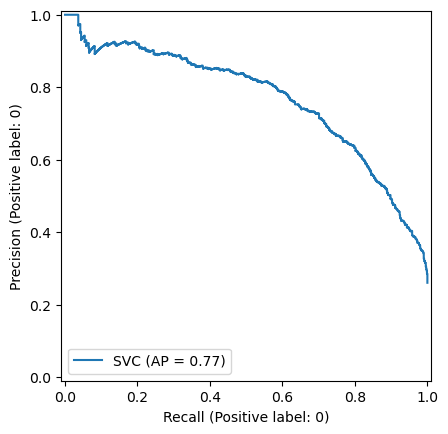

In [19]:
PrecisionRecallDisplay.from_estimator(model_svm, X_test_stacked, y_test_encoded,pos_label=0)


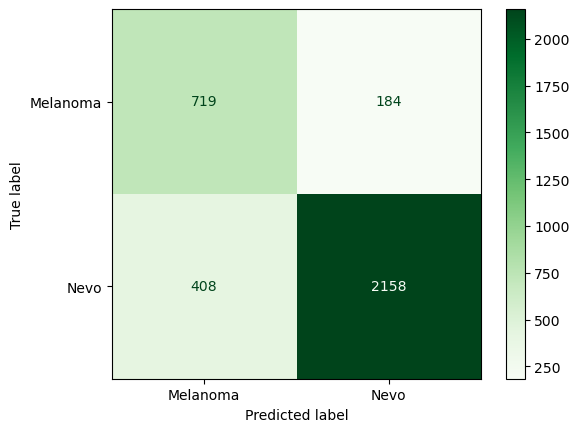

In [20]:
ConfusionMatrixDisplay.from_estimator(
    model_svm, X_test_stacked, y_test_encoded,
    display_labels=['Melanoma', 'Nevo'],
    cmap='Greens'
)

plt.show()


AUC: 0.8937554648098613


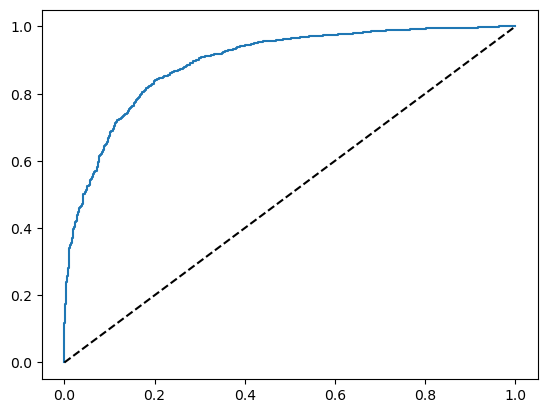

0.00641492829242174


In [37]:
from sklearn import metrics

y_scores = model_svm.decision_function(X_test_stacked)

fpr, tpr, thresholds = metrics.roc_curve(y_test_encoded, y_scores)


roc_auc = metrics.auc(fpr, tpr)
print("AUC:", roc_auc)

j = tpr - fpr

optimal_thres = thresholds[np.argmax(j)]


plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--') # Random guess line
plt.show()
print(optimal_thres)

In [ ]:
0.00641492829242174

In [ ]:
# from sklearn.metrics import precision_recall_curve

# precision, recall, thresholds = precision_recall_curve(y_test_encoded, y_scores, pos_label=0)

# idx = np.where(recall >= 0.82)[0][-1]
# idx = min(idx, len(thresholds) - 1)
# optimal_thres = thresholds[idx]
# print(f"Threshold: {thresholds[idx]}, Precision: {precision[idx]}, Recall: {recall[idx]}")

Threshold: 0.2563272878489186, Precision: 0.6044045676998369, Recall: 0.8205980066445183


In [ ]:
y_probs = model_svm.predict_proba(X_test_stacked)

y_pred = (y_scores >= optimal_thres).astype(int)

y_pred = 1-y_pred

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.82      0.70       903
           1       0.93      0.81      0.87      2566

    accuracy                           0.81      3469
   macro avg       0.77      0.82      0.78      3469
weighted avg       0.84      0.81      0.82      3469



In [25]:
ConfusionMatrixDisplay.from_predictions(
   y_test_encoded, y_pred,
    display_labels=['Melanoma', 'Nevo'],
    cmap='Greens'
)

plt.show()

NameError: name 'y_pred' is not defined

In [ ]:
joblib.dump(model_svm, './data/model_svm_final.pkl')
joblib.dump(scaler_classic, './data/scaler_classic.pkl')
joblib.dump(scaler_cnn, './data/scaler_cnn.pkl')
joblib.dump(label_encoder, './data/label_encoder.pkl')

['./data/label_encoder.pkl']